In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 323
TICKERS = ['NVDA', 'MSFT', 'META', 'AMZN', 'GOOGL']
PALETTE = ['#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261']

df = pd.read_csv('data/table2_price_targets.csv')
df['Date'] = pd.to_datetime(df['Date']).dt.normalize()
df = df[df['Ticker'].isin(TICKERS)].sort_values(['Ticker', 'Date']).reset_index(drop=True)


def bsadf_series(y, r0):
    """Vectorized BSADF. ADF(const, no lag): dy = a + b*x + e, t-stat on b.
       For each endpoint, all start points computed at once via prefix-sum diffs."""
    T = len(y)
    min_win = int(np.floor(r0 * T))
    dy = np.diff(y)                 # len T-1
    x = y[:-1]                      # len T-1

    cs_x  = np.concatenate([[0.0], np.cumsum(x)])
    cs_xx = np.concatenate([[0.0], np.cumsum(x * x)])
    cs_y  = np.concatenate([[0.0], np.cumsum(dy)])
    cs_yy = np.concatenate([[0.0], np.cumsum(dy * dy)])
    cs_xy = np.concatenate([[0.0], np.cumsum(x * dy)])

    bsadf = np.full(T, np.nan)
    for r2 in range(min_win, T + 1):
        end = r2 - 1                          # dy/x window end (exclusive)
        starts = np.arange(0, end - min_win + 2)   # all valid r1 for this end
        if starts.size == 0:
            continue
        n   = end - starts                    # window lengths, vector
        Sx  = cs_x[end]  - cs_x[starts]
        Sxx = cs_xx[end] - cs_xx[starts]
        Sy  = cs_y[end]  - cs_y[starts]
        Syy = cs_yy[end] - cs_yy[starts]
        Sxy = cs_xy[end] - cs_xy[starts]

        det = n * Sxx - Sx * Sx
        b_hat = np.where(det > 0, (n * Sxy - Sx * Sy) / np.where(det > 0, det, 1), np.nan)
        a_hat = (Sy - b_hat * Sx) / n
        rss = Syy - a_hat * Sy - b_hat * Sxy
        with np.errstate(invalid='ignore', divide='ignore'):
            s2 = rss / (n - 2)
            var_b = s2 * n / det
            tstat = b_hat / np.sqrt(var_b)
        tstat = np.where((n >= 3) & (det > 0) & (rss > 0) & (var_b > 0), tstat, -np.inf)
        bsadf[r2 - 1] = np.nanmax(tstat) if np.any(np.isfinite(tstat)) else np.nan
    return bsadf


def gsadf_critical_series(T, r0, n_sim=499, seed=SEED, quantile=0.95):
    rng = np.random.default_rng(seed)
    sim = np.full((n_sim, T), np.nan)
    for s in range(n_sim):
        w = np.cumsum(rng.standard_normal(T))
        sim[s] = bsadf_series(w, r0)
    cv = np.nanquantile(sim, quantile, axis=0)
    return cv

In [8]:
def detect_bubbles(ticker, n_sim=499, min_episode=None):
    sub = df[df['Ticker'] == ticker].reset_index(drop=True)
    dates = sub['Date'].values
    y = np.log(sub['Close_t'].values)
    T = len(y)
    r0 = 0.01 + 1.8 / np.sqrt(T)

    bsadf = bsadf_series(y, r0)
    cv = gsadf_critical_series(T, r0, n_sim=n_sim)

    gsadf_stat = np.nanmax(bsadf)
    gsadf_cv = np.nanmax(cv)

    signal = np.zeros(T, dtype=bool)
    valid = ~np.isnan(bsadf) & ~np.isnan(cv)
    signal[valid] = bsadf[valid] > cv[valid]      # pointwise, not scalar broadcast

    if min_episode is None:
        min_episode = int(np.floor(np.log(T)))

    episodes = []
    i = 0
    while i < T:
        if signal[i]:
            j = i
            while j < T and signal[j]:
                j += 1
            if (j - i) >= min_episode:
                episodes.append((dates[i], dates[j - 1], j - i))
            i = j
        else:
            i += 1

    verdict = 'REJECT null (bubble present)' if gsadf_stat > gsadf_cv else 'no bubble'
    print(f"{ticker}: GSADF={gsadf_stat:.3f}  CV(sup)={gsadf_cv:.3f}  {verdict}  "
          f"| min_episode={min_episode}d  n_episodes={len(episodes)}")
    for s, e, ln in episodes:
        print(f"   {pd.Timestamp(s).date()} -> {pd.Timestamp(e).date()}  ({ln}d)")

    return {'ticker': ticker, 'dates': dates, 'logprice': y,
            'bsadf': bsadf, 'cv': cv, 'signal': signal, 'episodes': episodes}


def plot_bubbles(res):
    dates, y, bsadf, cv = res['dates'], res['logprice'], res['bsadf'], res['cv']
    fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    fig.patch.set_facecolor('white')
    ax[0].plot(dates, y, color='#457B9D', lw=1.2)
    for s, e, _ in res['episodes']:
        ax[0].axvspan(s, e, color='#E63946', alpha=0.25)
    ax[0].set_ylabel('log(Close_t)')
    ax[0].set_title(f"{res['ticker']} — GSADF bubble detection (2021-2025)")
    ax[1].plot(dates, bsadf, color='#2A9D8F', lw=1.0, label='BSADF')
    ax[1].plot(dates, cv, color='#E63946', lw=1.0, ls='--', label='95% CV (pointwise)')
    ax[1].fill_between(dates, bsadf, cv, where=(bsadf > cv), color='#E63946', alpha=0.25)
    ax[1].set_ylabel('BSADF'); ax[1].legend(loc='upper left')
    plt.tight_layout(); plt.show()

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


NVDA: GSADF=2.198  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=9
   2021-11-04 -> 2021-12-02  (20d)
   2023-05-25 -> 2023-06-05  (7d)
   2023-06-08 -> 2023-06-27  (13d)
   2023-07-12 -> 2023-08-01  (15d)
   2024-02-01 -> 2024-02-20  (13d)
   2024-02-22 -> 2024-04-09  (33d)
   2024-05-14 -> 2024-07-29  (52d)
   2024-08-13 -> 2024-08-28  (12d)
   2024-11-06 -> 2024-11-22  (13d)


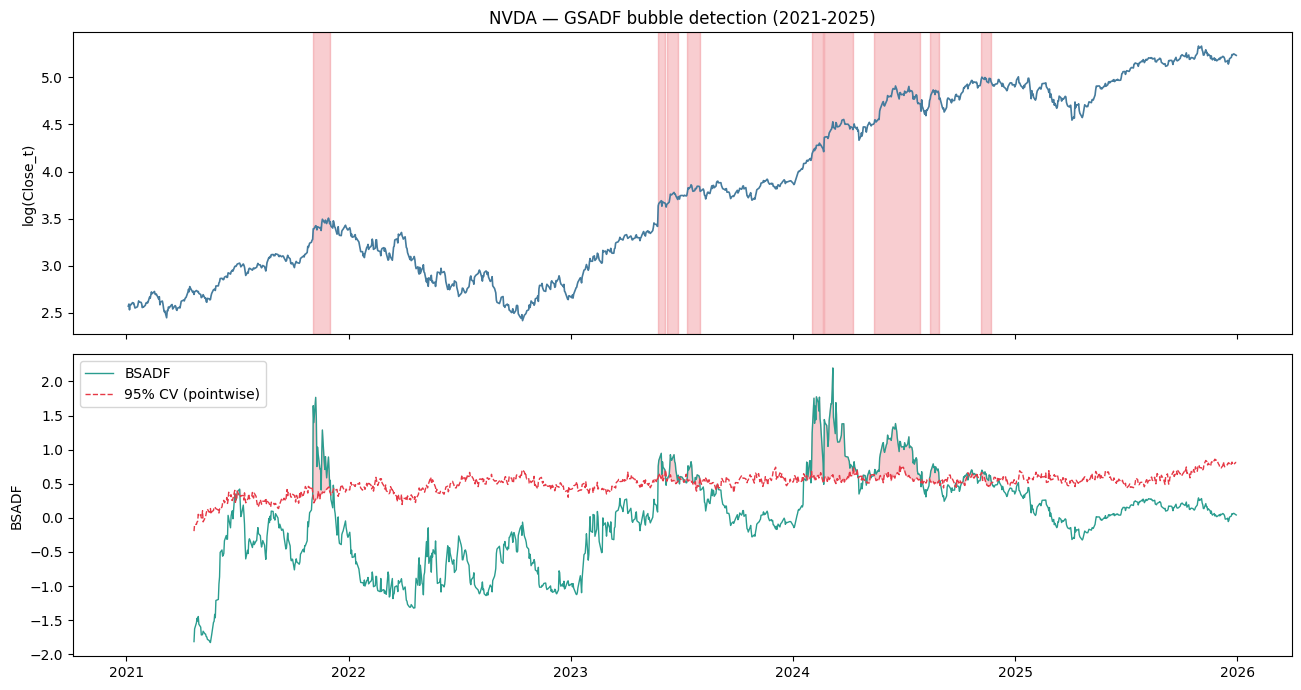

In [9]:
res_nvda = detect_bubbles('NVDA', n_sim=499)
plot_bubbles(res_nvda)

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


MSFT: GSADF=0.642  CV(sup)=0.861  no bubble  | min_episode=7d  n_episodes=0


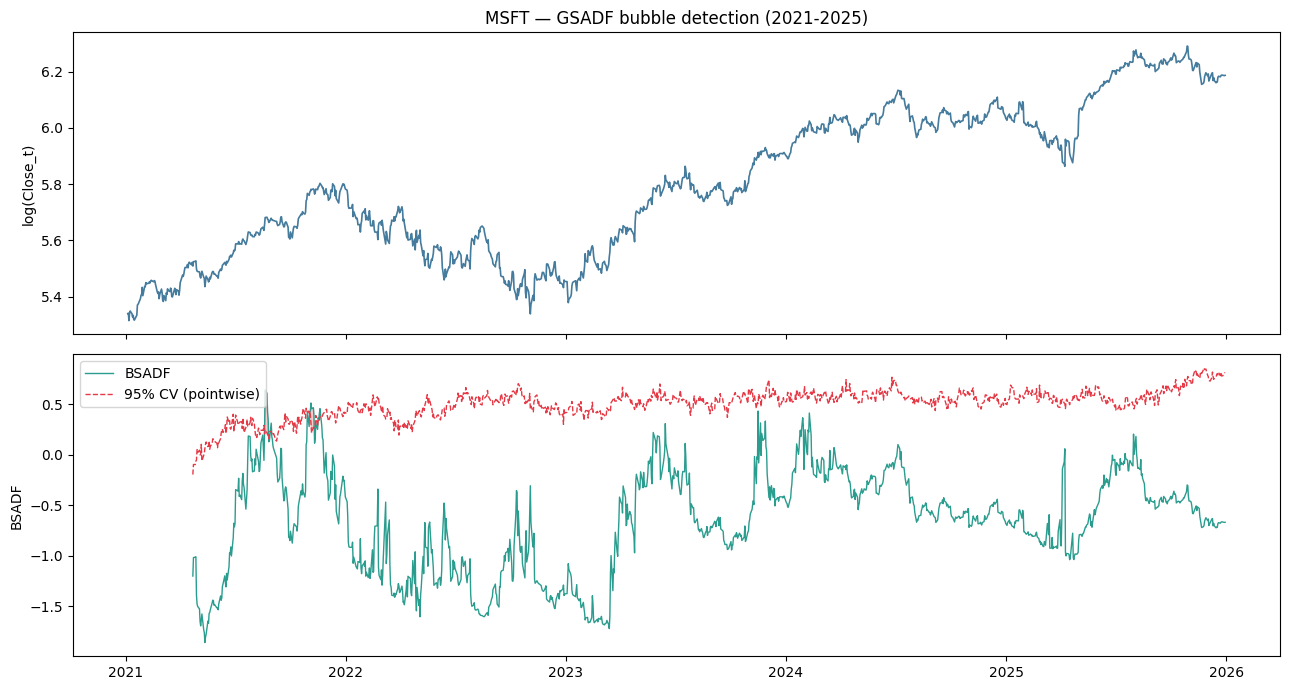

In [10]:
res_msft = detect_bubbles('MSFT', n_sim=499)
plot_bubbles(res_msft)

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


META: GSADF=1.678  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=4
   2022-03-03 -> 2022-03-15  (9d)
   2022-10-27 -> 2022-11-09  (10d)
   2024-02-02 -> 2024-02-12  (7d)
   2024-02-14 -> 2024-03-04  (13d)


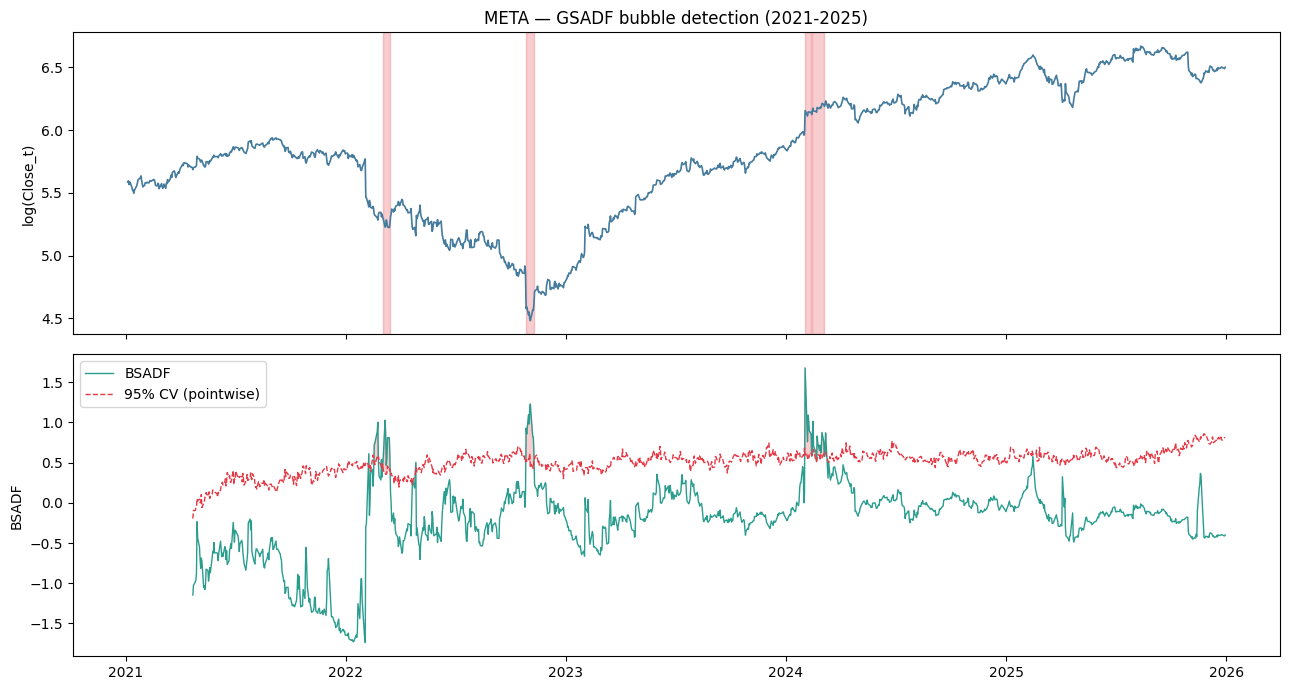

In [11]:
res_msft = detect_bubbles('META', n_sim=499)
plot_bubbles(res_msft)

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


AMZN: GSADF=0.928  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=0


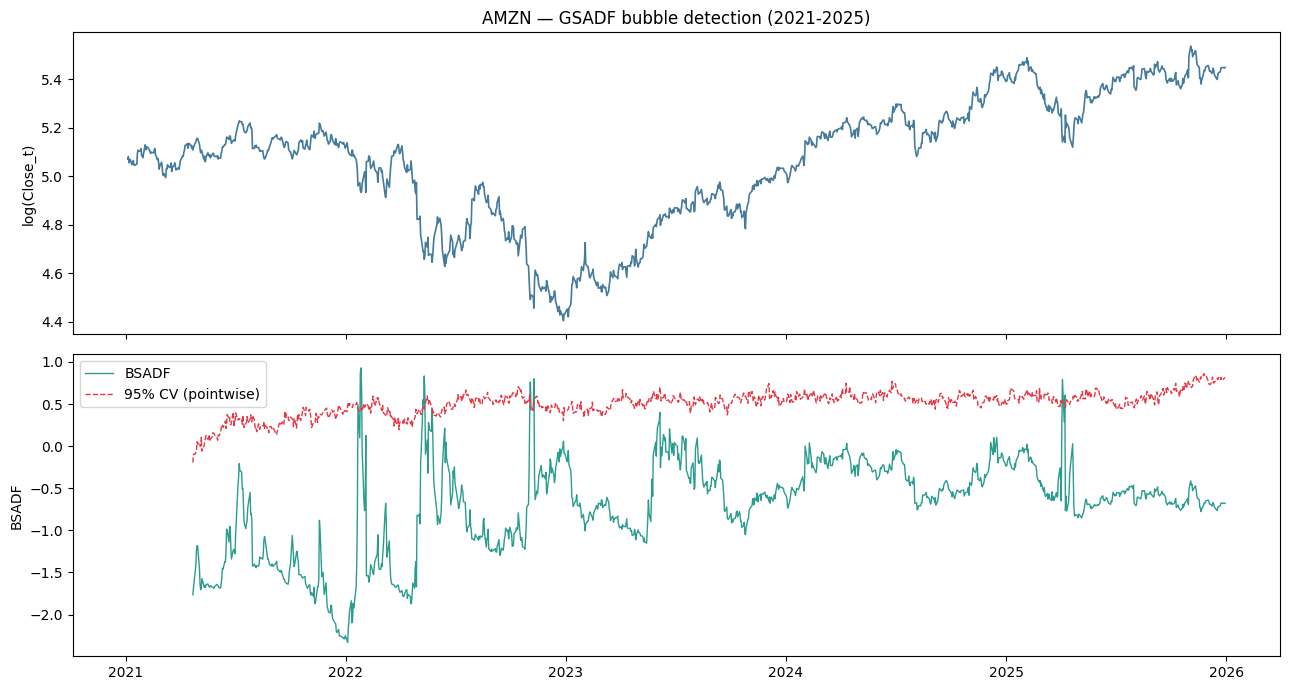

In [12]:
res_msft = detect_bubbles('AMZN', n_sim=499)
plot_bubbles(res_msft)

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


GOOGL: GSADF=1.499  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=3
   2021-08-24 -> 2021-09-01  (7d)
   2025-09-03 -> 2025-09-23  (15d)
   2025-11-21 -> 2025-12-11  (14d)


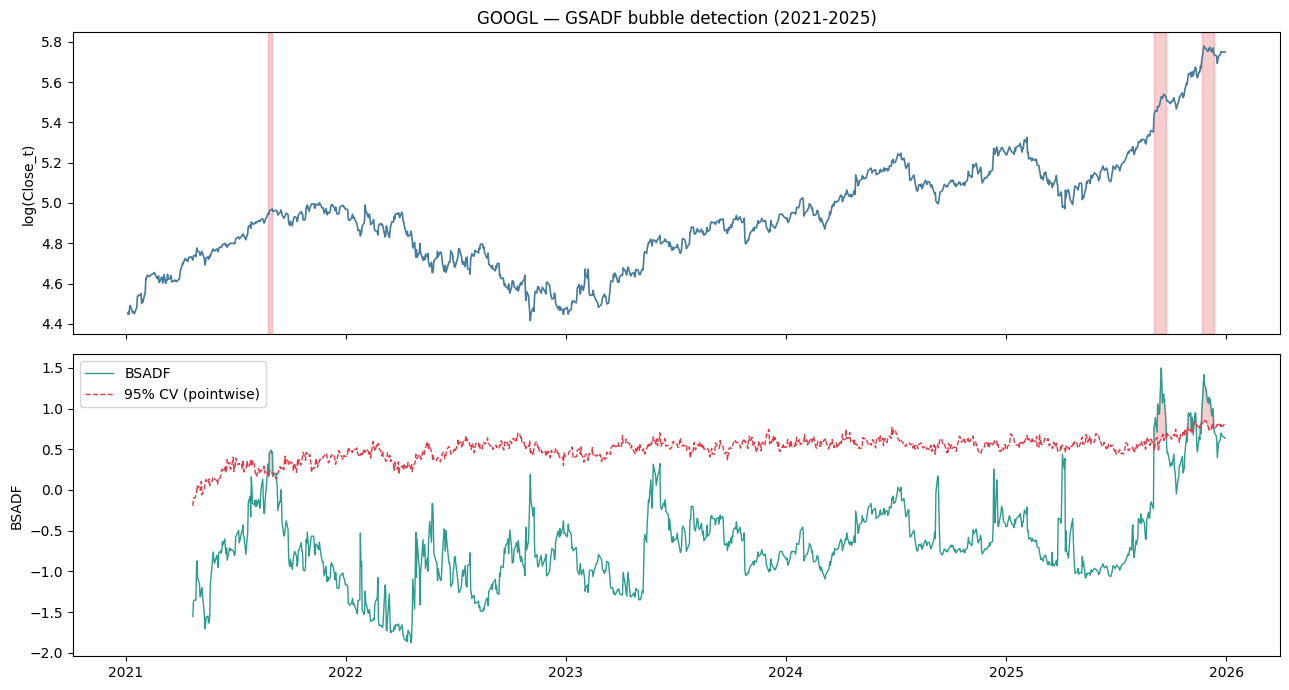

In [13]:
res_msft = detect_bubbles('GOOGL', n_sim=499)
plot_bubbles(res_msft)

In [14]:
res_amzn = detect_bubbles('AMZN', n_sim=499)

AMZN: GSADF=0.928  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=0


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [15]:
def diagnose(res):
    dates = res['dates']; bsadf = res['bsadf']; cv = res['cv']; sig = res['signal']
    T = len(sig)
    n_true = int(sig.sum())

    # all consecutive runs of True (no min-length filter)
    runs = []
    i = 0
    while i < T:
        if sig[i]:
            j = i
            while j < T and sig[j]:
                j += 1
            runs.append((dates[i], dates[j-1], j-i))
            i = j
        else:
            i += 1

    # where the sup GSADF statistic is attained
    k = int(np.nanargmax(bsadf))
    print(f"{res['ticker']}: total signal days={n_true}  raw runs={len(runs)}")
    print(f"  GSADF sup attained at {pd.Timestamp(dates[k]).date()}  "
          f"BSADF={bsadf[k]:.3f}  CV_at_that_point={cv[k]:.3f}")
    print(f"  run-length distribution: {sorted([r[2] for r in runs], reverse=True)}")
    print("  all raw runs (no min_episode filter):")
    for s, e, ln in runs:
        print(f"    {pd.Timestamp(s).date()} -> {pd.Timestamp(e).date()}  ({ln}d)")

diagnose(res_amzn)

AMZN: total signal days=13  raw runs=7
  GSADF sup attained at 2022-01-26  BSADF=0.928  CV_at_that_point=0.446
  run-length distribution: [4, 3, 2, 1, 1, 1, 1]
  all raw runs (no min_episode filter):
    2022-01-21 -> 2022-01-21  (1d)
    2022-01-25 -> 2022-01-27  (3d)
    2022-05-09 -> 2022-05-12  (4d)
    2022-11-03 -> 2022-11-03  (1d)
    2022-11-08 -> 2022-11-09  (2d)
    2025-04-04 -> 2025-04-04  (1d)
    2025-04-08 -> 2025-04-08  (1d)


In [16]:
results = {}
for tk in TICKERS:
    results[tk] = detect_bubbles(tk, n_sim=499)

c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


NVDA: GSADF=2.198  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=9
   2021-11-04 -> 2021-12-02  (20d)
   2023-05-25 -> 2023-06-05  (7d)
   2023-06-08 -> 2023-06-27  (13d)
   2023-07-12 -> 2023-08-01  (15d)
   2024-02-01 -> 2024-02-20  (13d)
   2024-02-22 -> 2024-04-09  (33d)
   2024-05-14 -> 2024-07-29  (52d)
   2024-08-13 -> 2024-08-28  (12d)
   2024-11-06 -> 2024-11-22  (13d)


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


MSFT: GSADF=0.642  CV(sup)=0.861  no bubble  | min_episode=7d  n_episodes=0


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


META: GSADF=1.678  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=4
   2022-03-03 -> 2022-03-15  (9d)
   2022-10-27 -> 2022-11-09  (10d)
   2024-02-02 -> 2024-02-12  (7d)
   2024-02-14 -> 2024-03-04  (13d)


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


AMZN: GSADF=0.928  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=0
GOOGL: GSADF=1.499  CV(sup)=0.861  REJECT null (bubble present)  | min_episode=7d  n_episodes=3
   2021-08-24 -> 2021-09-01  (7d)
   2025-09-03 -> 2025-09-23  (15d)
   2025-11-21 -> 2025-12-11  (14d)


c:\Users\jiayu\anaconda3\envs\news_stock\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


Ticker  GSADF  CV_sup Reject  N_episodes  Bubble_days Bubble_2025
  NVDA  2.198   0.861    Yes           9          178          No
  MSFT  0.642   0.861     No           0            0          No
  META  1.678   0.861    Yes           4           39          No
  AMZN  0.928   0.861    Yes           0            0          No
 GOOGL  1.499   0.861    Yes           3           36         Yes


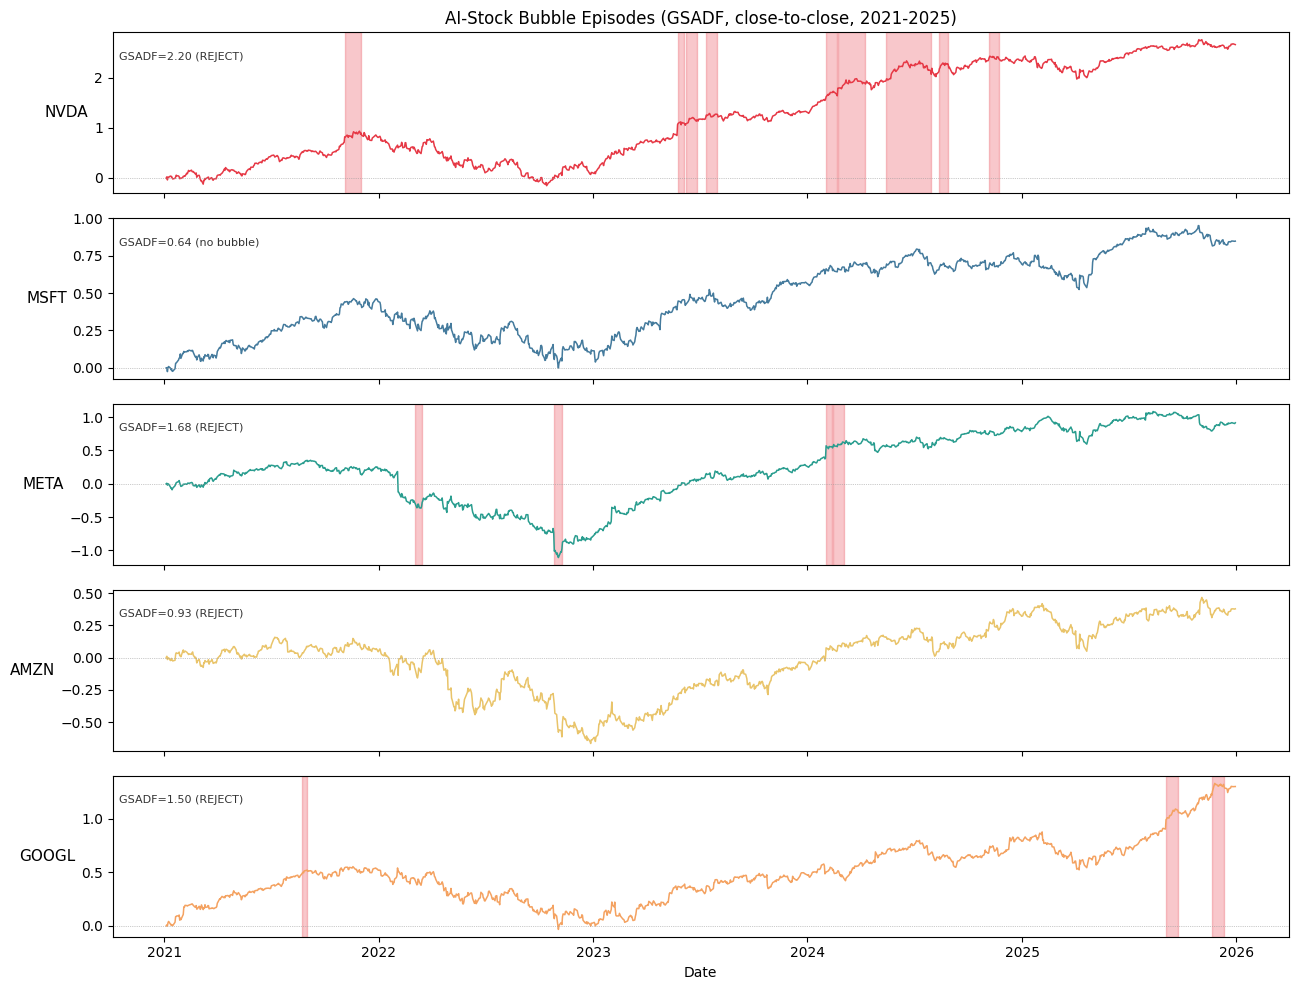

In [17]:
# ---- 汇总表 ----
rows = []
for tk in TICKERS:
    r = results[tk]
    gs = np.nanmax(r['bsadf']); cv = np.nanmax(r['cv'])
    eps = r['episodes']
    bubble_days = sum(e[2] for e in eps)
    has_2025 = any(pd.Timestamp(e[0]).year == 2025 or pd.Timestamp(e[1]).year == 2025 for e in eps)
    rows.append({
        'Ticker': tk,
        'GSADF': round(gs, 3),
        'CV_sup': round(cv, 3),
        'Reject': 'Yes' if gs > cv else 'No',
        'N_episodes': len(eps),
        'Bubble_days': bubble_days,
        'Bubble_2025': 'Yes' if has_2025 else 'No',
    })
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

# ---- 五合一时间轴图 ----
fig, axes = plt.subplots(len(TICKERS), 1, figsize=(13, 10), sharex=True)
fig.patch.set_facecolor('white')
for ax, tk, color in zip(axes, TICKERS, PALETTE):
    r = results[tk]
    dates, y = r['dates'], r['logprice']
    # normalize log-price to start at 0 for visual comparability
    y0 = y - y[0]
    ax.plot(dates, y0, color=color, lw=1.1)
    for s, e, _ in r['episodes']:
        ax.axvspan(s, e, color='#E63946', alpha=0.28)
    gs = np.nanmax(r['bsadf']); cv = np.nanmax(r['cv'])
    tag = 'REJECT' if gs > cv else 'no bubble'
    ax.set_ylabel(tk, rotation=0, ha='right', va='center', fontsize=11)
    ax.text(0.005, 0.88, f"GSADF={gs:.2f} ({tag})", transform=ax.transAxes,
            fontsize=8, color='#333', va='top')
    ax.axhline(0, color='#999', lw=0.5, ls=':')
axes[0].set_title('AI-Stock Bubble Episodes (GSADF, close-to-close, 2021-2025)', fontsize=12)
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('output/bubble_timeline_5stocks.png', dpi=150, bbox_inches='tight')
plt.show()